<div class="alert alert-block alert-info">
<b>Linear Regression - </b>It computes the linear relationship between the dependent variable and one or more independent features by fitting a linear equation with observed data
</div>

In [95]:
import pandas as pd

<div class="alert alert-block alert-success">
<b>Independent and Dependant variables:</b> weight will be the independant features
and the height will be the dependent features.
</div>

In [96]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline


<div class="alert alert-block alert-success">
<b>pd.read_csv:</b> Read the data set
</div>

In [97]:
data = pd.read_csv('weight-height.csv')
data.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [98]:
# plt.figure(figsize=(20, 16)) 
%matplotlib inline
plt.rcParams["figure.figsize"] = (8, 6)


Text(0.5, 1.0, 'Weight vs Height')

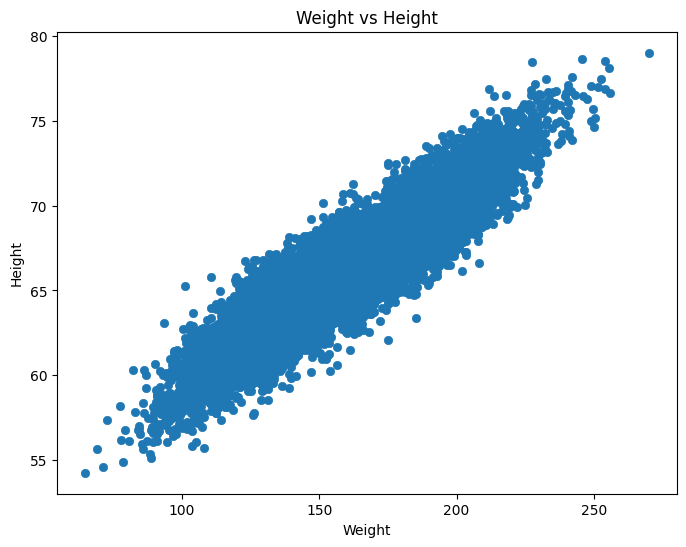

In [99]:

plt.scatter(data['Weight'], data['Height'], linewidths=0.5)
plt.xlabel('Weight')
plt.ylabel('Height')
plt.title('Weight vs Height')

In [100]:
from sklearn.model_selection import train_test_split

In [101]:
## divide the data into independent and dependant features
X = data[['Weight']] # independent feature
y = data[['Height']] # dependent feature

In [102]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [103]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((8000, 1), (2000, 1), (8000, 1), (2000, 1))

In [104]:
X_train.head()

,Weight
9254,120.681907
1561,209.373126
1670,200.877279
6087,134.342745
6669,160.201031


In [105]:
## standardize the dataset Train independent data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [106]:
X_train = scaler.fit_transform(X_train) # fit = calculate mean and std, transform = apply the formula Z = (X - mean)/std
X_test = scaler.transform(X_test) # only transform because we have already calculated the mean and std it will use the same mean and std and apply the formula

# Reason I am doing it - My model shoudl Not know anything about the test data, it just have the information of the test data.

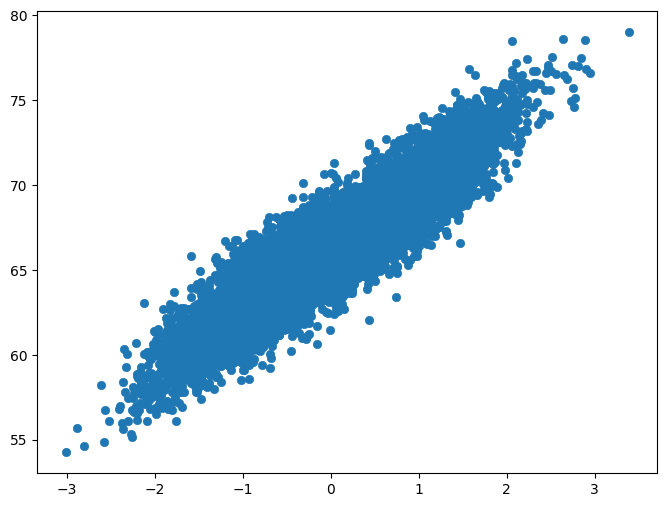

In [107]:
plt.scatter(X_train, y_train, linewidths=0.5)

In [108]:
# Train the linear Regression Model
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()

In [109]:
regressor.fit(X_train, y_train)

LinearRegression()

In [110]:
print('The slope or coeffiecent of weight is', regressor.coef_)
print('Intercept is', regressor.intercept_)

The slope or coeffiecent of weight is [[3.55479288]]
Intercept is [66.35968141]


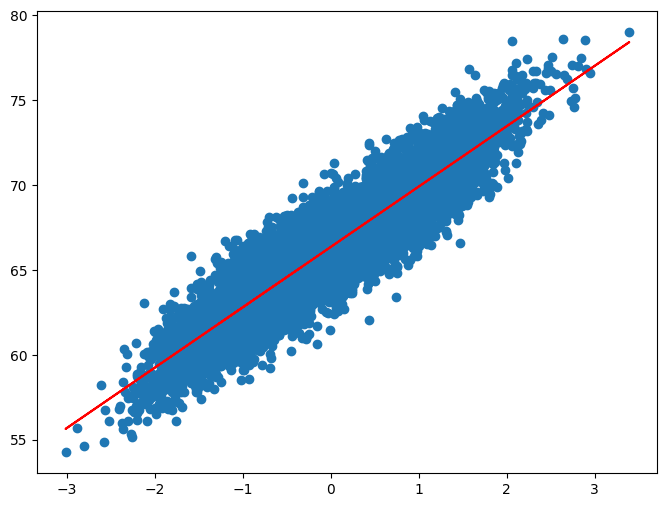

In [111]:
plt.scatter(X_train, y_train)
plt.plot(X_train, regressor.predict(X_train), color='red')
#best fit line

### prediction of train data
1. predicted height output = intercept + coef_(Weights)
2. y_pred_train = 68.6966 + 2.2731 *  ---- net to work on it.

### prediction of test data
1. predicted height output = intercept + coef_ (Weights)
2. y_pred_test = 68.6966 + 2.2731 *   ---- need to work on it.

In [112]:
y_pred_test = regressor.predict(X_test)
y_pred_test, y_test

(array([[67.66759668],
        [70.11347651],
        [67.34604311],
        ...,
        [62.34937415],
        [69.27157847],
        [59.829821  ]], shape=(2000, 1)),
          Height
 6252  68.687232
 4684  68.829334
 1731  66.398128
 4742  71.929340
 4521  67.042903
 ...         ...
 6412  65.748601
 8285  60.731857
 7853  62.188933
 1095  67.068304
 6929  58.632720
 
 [2000 rows x 1 columns])

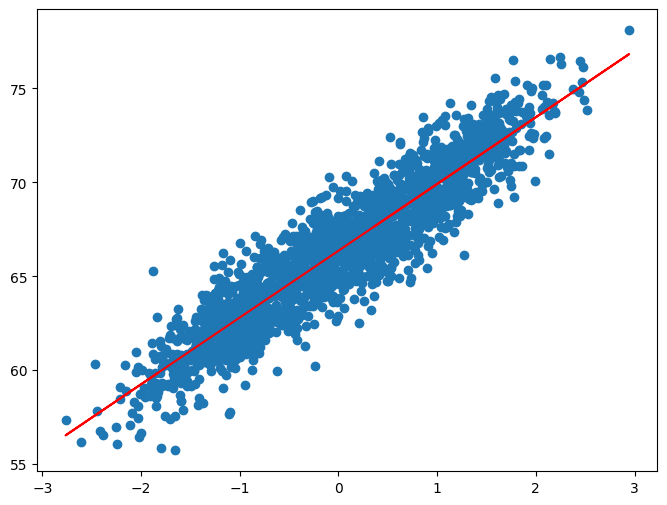

In [113]:
plt.scatter(X_test, y_test)
plt.plot(X_test,regressor.predict(X_test), color='red')

In [114]:
## Performance Matrix
# Mean Squared Error, Mean Absolute Error, Root Mean Squared Error,
## adjusted R2, R2

In [115]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
mse = mean_squared_error(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
print('Mean Squared Error is', mse)
print('Mean Absolute Error is', mae)
print('Root Mean Squared Error is', rmse)

Mean Squared Error is 2.112361948474147
Mean Absolute Error is 1.1588656330992098
Root Mean Squared Error is 1.4533966934303062


In [116]:
from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred_test)
print('R2 Score is', score)

R2 Score is 0.8578120230894554


In [117]:
adjuted_r2 = 1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)
print('Adjusted R2 Score is', adjuted_r2)

Adjusted R2 Score is 0.8577408579358465


In [118]:
## Predict the height of a person with weight 80kg = 176.37 pound
scaled_weight = scaler.transform([[186]])
scaled_weight

d:\AI-ML-learning\Multi Regression\myenv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.77003884]])

In [119]:
print(regressor.predict([scaled_weight[0]])) # 2.54 cm = 1 inch

[[69.09701]]


# Assumptions
how we can say that our model is performin well.
1--plot the scatter plot for the preditcion -- if it is linear distributed that we can consider that the model is performing well.
2--Residuals - difference between y_test - y_pred_test,
if we plot the residual using histplot ,if we are getting the normal distribution(gaussain distrubution where left and right are equally distributed if we consider the mean of the graph.) then we can consider that the model is performing well. 
3-- Scatter plot with respect to prediction and residual
   (Uniform distribution - data points will be availabel in both positive and negative points)


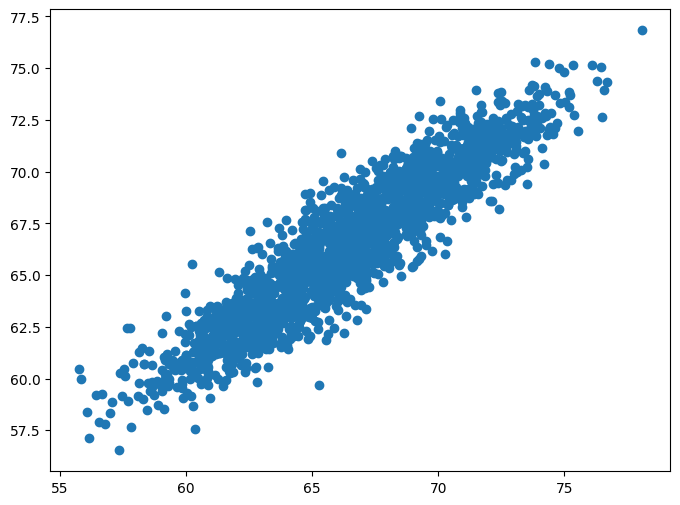

In [120]:
plt.scatter(y_test, y_pred_test)

In [121]:
residuals = y_test - y_pred_test


<Axes: ylabel='Count'>

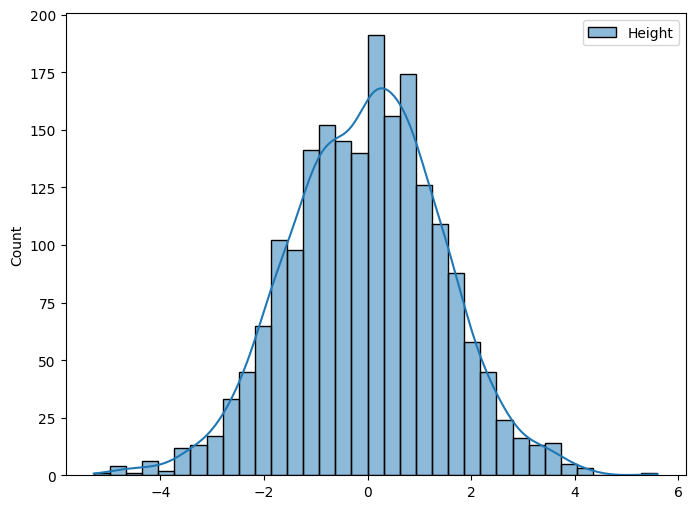

In [122]:
import seaborn as sns
sns.histplot(residuals,kde=True)

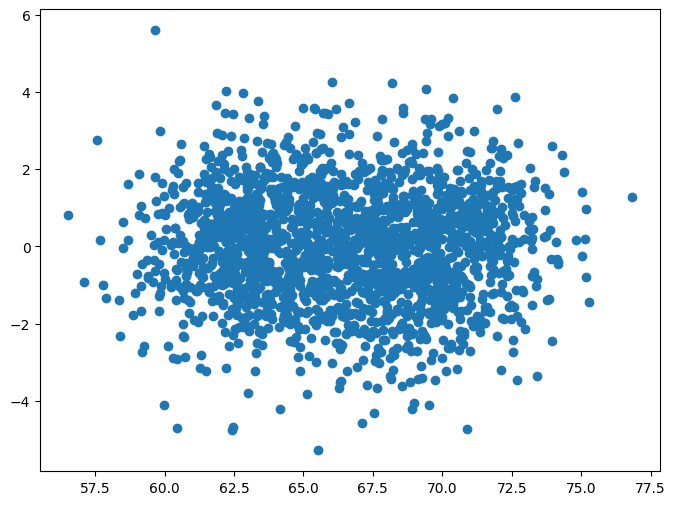

In [123]:
plt.scatter(y_pred_test, residuals)